## Public Transport Accessibility and House Prices

This analysis investigates whether neighbourhoods with better public transport accessibility tend to have higher median house prices across London LSOAs.

### 1. Exploratory Data Analysis (EDA)

Before performing statistical analysis, the distribution of public transport accessibility and house prices was explored to understand the characteristics of the data, identify potential outliers and assess whether the assumptions of subsequent analyses were reasonable.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.api as sm

In [17]:
final_df = pd.read_csv('data/final_dataset.csv')
df_transport = final_df[
    ['Local authority code', 
    'Local authority name', 
    'LSOA code', 'LSOA name', 
    'Median House Price 2022', 
    'Average PTAI 2015', 
    'PTAL']
].copy()

In [15]:
eda = pd.DataFrame({
    "Mean": df_transport[["Median House Price 2022", "Average PTAI 2015"]].mean(),
    "Median": df_transport[["Median House Price 2022", "Average PTAI 2015"]].median(),
    "Std": df_transport[["Median House Price 2022", "Average PTAI 2015"]].std(),
    "Min": df_transport[["Median House Price 2022", "Average PTAI 2015"]].min(),
    "Max": df_transport[["Median House Price 2022", "Average PTAI 2015"]].max(),
    "Skewness": df_transport[["Median House Price 2022", "Average PTAI 2015"]].skew()
}).round(2)

eda

,Mean,Median,Std,Min,Max,Skewness
Median House Price 2022,617912.52,520000.00,396308.60,147500.00,6425000.00,5.24
Average PTAI 2015,13.23,9.48,12.31,0.19,121.89,2.92


Descriptive statistics show that both median house prices and public transport accessibility are positively skewed, with house prices exhibiting particularly strong skewness (5.24). The median house price (£520,000) is lower than the mean (£617,913), reflecting the presence of a relatively small number of very expensive neighbourhoods. Similarly, PTAI values range from 0.19 to 121.89, with a median of 9.48, indicating that only a small number of LSOAs have exceptionally high public transport accessibility.

C:\Users\Olesya Drozhzhina\AppData\Local\Temp\ipykernel_23600\4144076397.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = plt.boxplot(


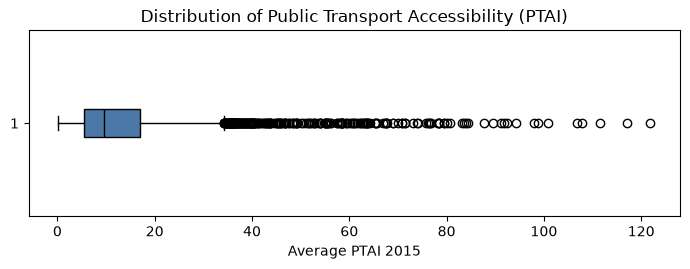

In [34]:
plt.figure(figsize=(7, 2.8))

bp = plt.boxplot(
    df_transport["Average PTAI 2015"],
    vert=False,
    patch_artist=True
)

bp["boxes"][0].set_facecolor("#4c78a8") 
bp["medians"][0].set_color("black")

plt.title("Distribution of Public Transport Accessibility (PTAI)")
plt.xlabel("Average PTAI 2015")

plt.tight_layout()
plt.show()

In [7]:
df_transport.nlargest(10,"Average PTAI 2015")

,Local authority code,Local authority name,LSOA code,LSOA name,Median House Price 2022,Average PTAI 2015,PTAL
4591,E09000028,Southwark,E01032584,Southwark 034E,562500,121.8870,6b
4589,E09000022,Lambeth,E01032582,Lambeth 036E,1060300,117.0410,6b
4601,E09000001,City of London,E01032739,City of London 001F,756250,111.4790,6b
2893,E09000022,Lambeth,E01003017,Lambeth 036D,777000,107.8610,6b
2892,E09000022,Lambeth,E01003016,Lambeth 036C,875000,106.8410,6b
4590,E09000028,Southwark,E01032583,Southwark 034D,740500,100.9260,6b
3779,E09000028,Southwark,E01003930,Southwark 034A,513750,98.7026,6b
4541,E09000033,Westminster,E01004734,Westminster 018A,1212500,97.9024,6b
4542,E09000033,Westminster,E01004735,Westminster 018B,1525000,94.2208,6b
3778,E09000028,Southwark,E01003929,Southwark 002B,730000,92.3200,6b


The boxplot shows a long right tail with many high PTAI values beyond the 1.5 × IQR threshold. Inspection of the highest values confirmed that these correspond to central London neighbourhoods with exceptionally good public transport accessibility rather than data errors. As these represent genuine characteristics rather than data errors, they were retained in the analysis.

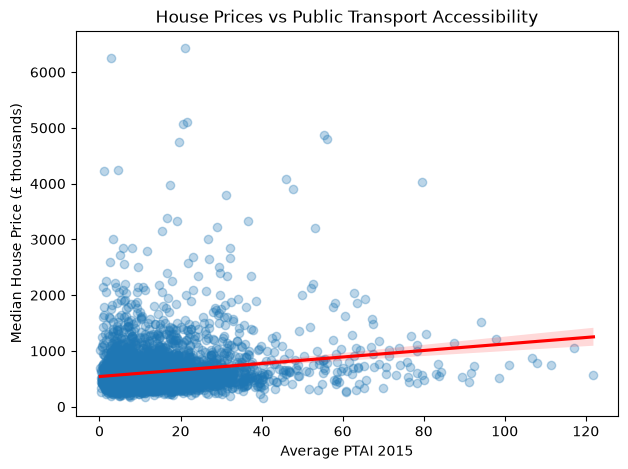

In [31]:
plt.figure(figsize=(7,5))

sns.regplot(
    x=df_transport["Average PTAI 2015"],
    y=df_transport["Median House Price 2022"] / 1000,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title('House Prices vs Public Transport Accessibility')
plt.xlabel('Average PTAI 2015')
plt.ylabel('Median House Price (£ thousands)')


plt.show()

The scatter plot suggests a weak positive relationship between public transport accessibility and median house prices. Areas with better transport accessibility tend to have slightly higher house prices, although there is substantial variation, indicating that transport accessibility alone is not a strong predictor of house prices

### 2. Pearson Correlation

Pearson's correlation coefficient was calculated to measure the strength and direction of the linear relationship between public transport accessibility and median house prices.

Hypotheses

H₀: There is no linear relationship between public transport accessibility and house prices.

H₁: There is a positive linear relationship between public transport accessibility and house prices.

In [ ]:
r, p = pearsonr(df_transport["Average PTAI 2015"], df_transport["Median House Price 2022"])

print(f"Pearson correlation coefficient (r): {r:.3f}")
print(f"P-value: {p:.6f}")

Pearson correlation coefficient (r): 0.181
P-value: 0.000000


A weak positive correlation was found between public transport accessibility and house prices (r = 0.181, p < 0.001). Although the relationship is statistically significant, its strength is weak, indicating that transport accessibility alone explains only a small proportion of the variation in house prices.

### 3. Simple Linear Regression

A simple linear regression model was fitted to quantify the relationship between public transport accessibility and house prices and estimate the expected change in house price associated with increasing transport accessibility.

Hypotheses

H₀: The regression coefficient for public transport accessibility equals zero.

H₁: The regression coefficient is greater than zero.

In [ ]:
X = df_transport["Average PTAI 2015"]
y = df_transport["Median House Price 2022"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Median House Price 2022   R-squared:                       0.033
Model:                                 OLS   Adj. R-squared:                  0.033
Method:                      Least Squares   F-statistic:                     161.4
Date:                     Wed, 22 Jul 2026   Prob (F-statistic):           2.16e-36
Time:                             22:55:40   Log-Likelihood:                -67987.
No. Observations:                     4757   AIC:                         1.360e+05
Df Residuals:                         4755   BIC:                         1.360e+05
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

A simple linear regression was used to investigate whether public transport accessibility predicts median house prices. The model was statistically significant (p < 0.001), indicating that areas with better public transport accessibility tend to have higher house prices. The estimated coefficient suggests that each one-point increase in Average PTAI is associated with an increase of approximately £5,834 in median house price.

However, the model explained only 3.3% of the variation in house prices (R² = 0.033), indicating that public transport accessibility alone is a relatively weak predictor and that other neighbourhood characteristics also contribute to house prices.

### 4. Mann–Whitney U Test

To compare neighbourhoods with substantially different levels of transport accessibility, LSOAs were divided into the bottom and top quartiles of PTAI. Since house prices are highly skewed, the non-parametric Mann–Whitney U test was used instead of a t-test.

Hypotheses

H₀: House prices in areas with high transport accessibility are not higher than those in areas with low transport accessibility.

H₁: House prices in areas with high transport accessibility are higher than those in areas with low transport accessibility.

In [ ]:
low_ptai = df_transport["Average PTAI 2015"].quantile(0.25)
high_ptai = df_transport["Average PTAI 2015"].quantile(0.75)

low_group = df_transport[df_transport["Average PTAI 2015"] <= low_ptai]["Median House Price 2022"]

high_group = df_transport[df_transport["Average PTAI 2015"] >= high_ptai]["Median House Price 2022"]

print(f"Bottom 25% threshold: {low_ptai:.2f}")
print(f"Top 25% threshold: {high_ptai:.2f}")

print(f"Low PTAI observations: {len(low_group)}")
print(f"High PTAI observations: {len(high_group)}")

Bottom 25% threshold: 5.47
Top 25% threshold: 16.97
Low PTAI observations: 1190
High PTAI observations: 1190


In [18]:
summary = pd.DataFrame({
    "Low PTAI": low_group.describe(),
    "High PTAI": high_group.describe()
})

summary.style.format("{:,.0f}")

,Low PTAI,High PTAI
count,"1,190","1,190"
mean,"582,791","727,168"
std,"359,637","556,955"
min,"183,000","147,500"
25%,"415,250","450,000"
50%,"500,000","585,000"
75%,"644,375","787,026"
max,"6,250,000","6,425,000"


Text(0, 0.5, 'Median House Price (£ thousands)')

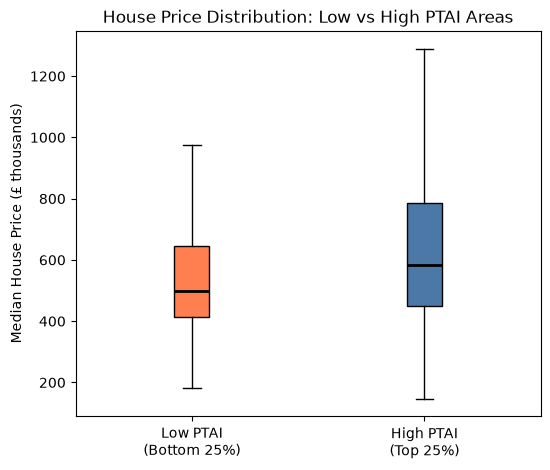

In [36]:
fig, ax = plt.subplots(figsize=(6, 5))

bp = ax.boxplot(
    [low_group/1000, high_group/1000],
    tick_labels=["Low PTAI\n(Bottom 25%)", "High PTAI\n(Top 25%)"],
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    boxprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)

colors = ["#ff7f50", "#4c78a8"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_title("House Price Distribution: Low vs High PTAI Areas")
ax.set_ylabel("Median House Price (£ thousands)")



In [ ]:
from scipy.stats import mannwhitneyu

u_stat, p = mannwhitneyu(low_group, high_group, alternative="less")

print(f"U statistic: {u_stat}")
print(f"P-value: {p:.6g}")

U statistic: 561887.5
P-value: 1.39472e-18


The Mann–Whitney U test indicated that neighbourhoods with higher public transport accessibility had significantly higher house prices than those with lower accessibility (U = 561,887.5, p < 0.001). Therefore, the null hypothesis was rejected.

### 5. Recommendations

All three analyses produced consistent results. Public transport accessibility was positively associated with house prices, and this relationship was statistically significant. However, both the correlation coefficient and the regression model indicated that transport accessibility alone explains only a small proportion of variation in house prices. This suggests that while transport accessibility contributes to property values, other neighbourhood characteristics such as deprivation, crime and local housing market conditions are also important.

Improving public transport accessibility may contribute to higher property values, but transport alone is unlikely to transform neighbourhood housing markets. Policymakers and urban planners should therefore consider transport investment alongside broader regeneration initiatives, including improvements in safety, local services and neighbourhood quality.